In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
diabetes = datasets.load_diabetes()
X = diabetes.data
y = diabetes.target
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Mean Squared Error: 2900.19
R^2 Score: 0.45


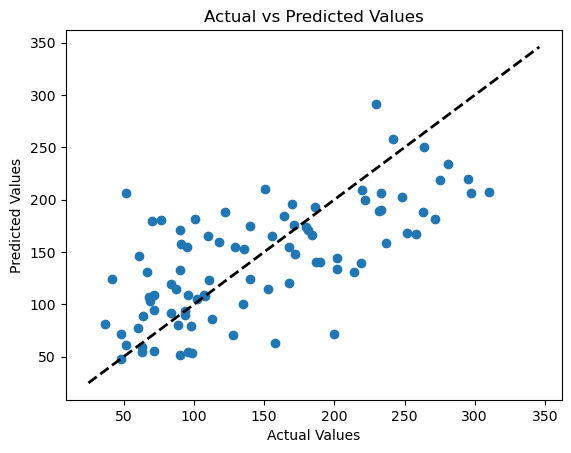

In [3]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R^2 Score: {r2:.2f}')
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.show()

Ridge Regression (Custom) - Mean Squared Error: 3077.42, R^2 Score: 0.42
Ridge Regression (Sklearn) - Mean Squared Error: 3077.42, R^2 Score: 0.42


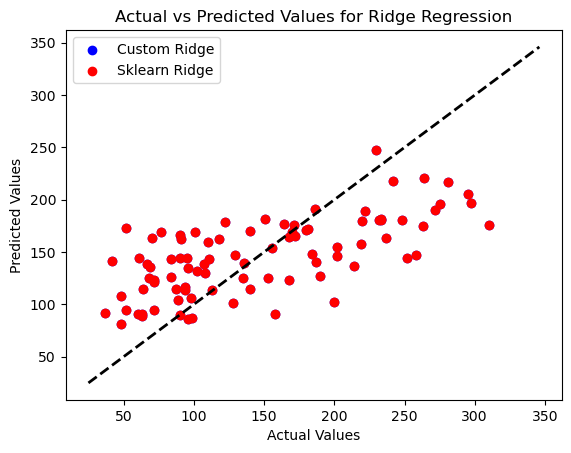

In [10]:
class RidgeRegression:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        X_b = np.hstack([np.ones((n_samples, 1)), X])
        I = np.eye(n_features + 1)
        I[0, 0] = 0
        self.coef_ = np.linalg.inv(X_b.T @ X_b + self.alpha * I) @ X_b.T @ y
        self.intercept_ = self.coef_[0]
        self.coef_ = self.coef_[1:]

    def predict(self, X):
        return X @ self.coef_ + self.intercept_

from sklearn.linear_model import Ridge

ridge_model = RidgeRegression(alpha=1.0)
ridge_sklearn_model = Ridge(alpha=1.0)
ridge_sklearn_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
y_pred_ridge_sklearn = ridge_sklearn_model.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
mse_ridge_sklearn = mean_squared_error(y_test, y_pred_ridge_sklearn)
r2_ridge_sklearn = r2_score(y_test, y_pred_ridge_sklearn)
print(f'Ridge Regression (Custom) - Mean Squared Error: {mse_ridge:.2f}, R^2 Score: {r2_ridge:.2f}')
print(f'Ridge Regression (Sklearn) - Mean Squared Error: {mse_ridge_sklearn:.2f}, R^2 Score: {r2_ridge_sklearn:.2f}')
plt.scatter(y_test, y_pred_ridge, color='blue', label='Custom Ridge')
plt.scatter(y_test, y_pred_ridge_sklearn, color='red', label='Sklearn Ridge')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values for Ridge Regression')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.legend()
plt.show()